# 02-06 - Moran's I by Hand

The lecture put one number on its grid of cells and said that the same values shuffled over the same cells give about zero. In this notebook we compute that number ourselves, in four lines of numpy, about fifteen with the test and the picture, from the grid we shipped and the very functions that drew the lecture's figures. Then we ask the same question of the tax blocks, where the first honest answer is that nobody has said who is next to whom.

This notebook is self-paced and not assessed. Save your own copy first, with `-mywork` in the name.

In [1]:
import json
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd
import mapclassify
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.geometry import box
import seaborn as sns

warnings.filterwarnings("ignore", message="Numba not installed")   # the one warning this course silences, see 02-03
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## The grid, and what is in it

The grid is the one 02-03 classified, 250 m squares laid over the P01 boundary, each carrying `n`, the number of buildings whose centroid falls inside it. The buildings are the OpenStreetMap extract from P01, mapped by volunteers and licensed ODbL, so the grid inherits that attribution and its own metadata says so. We also read the reference numbers the pipeline computed, so that everything we compute here can be compared with something:

In [2]:
grid = gpd.read_file("data/princeton_grid_250m.gpkg", layer="grid")
reference = json.load(open("data/ground_truth.json"))["p02"]

print(f"cells      {len(grid)}    reference {reference['grid']['cells']}")
print(f"buildings  {int(grid['n'].sum())}   reference {reference['grid']['buildings']}")
print(f"crs        {grid.crs}")

cells      839    reference 839
buildings  7893   reference 7893
crs        EPSG:26918


## Rebuilding it, to be sure it is the same

A shipped file is a claim. Here is the code that made it, two functions exactly as they appear in the script that drew the lecture's figures. `make_grid` lays square cells over the boundary's bounding box and keeps the ones that touch the town. `count_into` drops each building's centroid into a cell and counts:

In [3]:
def make_grid(bnd, step=250, offset=0.0):
    minx, miny, maxx, maxy = bnd.total_bounds
    cells = [box(x, y, x + step, y + step)
             for x in np.arange(minx + offset, maxx, step)
             for y in np.arange(miny + offset, maxy, step)]
    g = gpd.GeoDataFrame(geometry=cells, crs=bnd.crs)
    return g[g.intersects(bnd.geometry.iloc[0])].reset_index(drop=True)


def count_into(grid, points_or_polys, column):
    g = points_or_polys.copy()
    if g.geom_type.isin(["Polygon", "MultiPolygon"]).any():
        g = g.set_geometry(g.geometry.centroid)
    j = gpd.sjoin(g[["geometry"]], grid, predicate="within")
    grid = grid.copy()
    grid[column] = j.groupby("index_right").size().reindex(grid.index).fillna(0).astype(int)
    return grid

In [4]:
boundary = gpd.read_file("data/princeton_boundary.geojson").to_crs(grid.crs)
buildings = gpd.read_file("data/princeton_buildings.geojson").to_crs(grid.crs)

rebuilt = count_into(make_grid(boundary), buildings, "n")
print(f"{len(rebuilt)} cells rebuilt, identical counts: {np.array_equal(rebuilt['n'].values, grid['n'].values)}")

839 cells rebuilt, identical counts: True


Cell for cell. The lecture's figure, the pipeline that shipped the file and your kernel now agree, which is the only sense in which a number on a slide is ever checked. Note that the boundary and the buildings arrived in degrees and were converted to the grid's metres before anything else. `make_grid` in degrees would have laid a single square 250 degrees on a side over most of the planet, kept it, and not complained.

## A histogram cannot see space

The wrong intuition first, executed. Take the 839 counts, shuffle them over the same cells, and look at the real and the shuffled version with the tools of a first statistics course:

identical sorted values: True


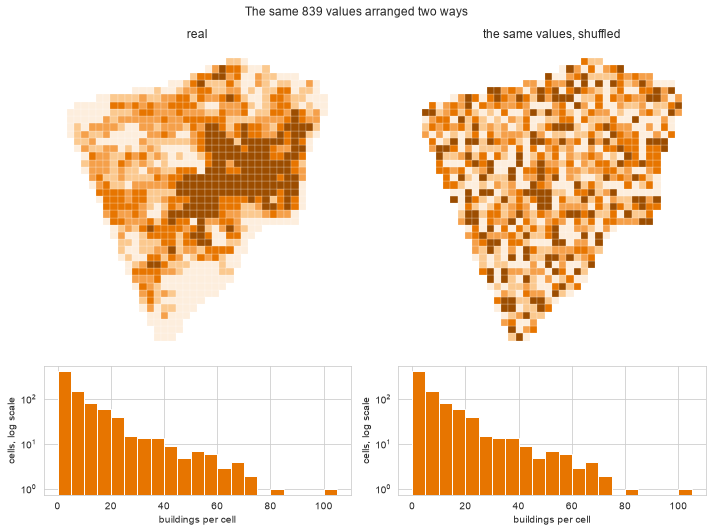

In [5]:
real = grid["n"].values.astype(float)
shuffled = np.random.default_rng(reference["moran"]["seed"]).permutation(real)
print(f"identical sorted values: {np.array_equal(np.sort(real), np.sort(shuffled))}")

ORANGES = ListedColormap(["#fdeedd", "#fbc98f", "#f5a04a", "#e77500", "#9c4d00"])

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), gridspec_kw={"height_ratios": [2.4, 1]})
for ax, values, label in ((axes[0][0], real, "real"), (axes[0][1], shuffled, "the same values, shuffled")):
    g = grid.copy()
    g["klass"] = mapclassify.Quantiles(values, k=5).yb   # the class number, 0 to 4, under five quantile breaks
    g.plot(ax=ax, column="klass", cmap=ORANGES, vmin=-0.5, vmax=4.5, edgecolor="white", linewidth=0.2)
    ax.set_title(label)
    ax.set_axis_off()
for ax, values in ((axes[1][0], real), (axes[1][1], shuffled)):
    ax.hist(values, bins=np.arange(0, 110, 5), color="#e77500", edgecolor="white")
    ax.set_yscale("log")
    ax.set_xlabel("buildings per cell")
    ax.set_ylabel("cells, log scale")
fig.suptitle(f"The same {len(grid)} values arranged two ways")
fig.tight_layout()

Same mean, same median, same quantile breaks, and the same histogram bar for bar, counted on a logarithmic axis so that the long tail is visible at all. And two maps that could not be more different. Every summary statistic from a first course is blind to the difference, because none of them knows where a value sits. Moran's I is the number that does.

## Who is next to whom

Spatial autocorrelation is a statement about neighbours, so the first decision is who counts as one. On a grid the natural answer is the cells that touch, corners included, which the jargon calls **queen contiguity**. Here is that decision as code, the same three lines the lecture's script used:

In [6]:
def neighbours(gdf):
    nb = gpd.sjoin(gdf[["geometry"]], gdf[["geometry"]], predicate="touches")
    return np.asarray(nb.index), np.asarray(nb["index_right"])


i_idx, j_idx = neighbours(grid)
per_cell = np.bincount(i_idx, minlength=len(grid))
print(f"{len(i_idx)} neighbour pairs, {per_cell.mean():.2f} per cell on average, from {per_cell.min()} to {per_cell.max()}")

6344 neighbour pairs, 7.56 per cell on average, from 3 to 8


An interior cell has eight neighbours and a cell on the town's edge fewer, and every pair appears twice, once from each side, which is what lets `np.bincount` count each cell's neighbours and what the spatial lag further down needs. Note that the I in the next cell would come out the same if each pair were listed once, because the number of pairs divides out of it. What does change it is the definition itself. `touches` is a decision, not a fact about the world. A different one, say every cell within a kilometre, gives a different I, and a report that states I without saying which neighbours it used has left out half of the number.

## The formula, in code

Moran's I asks, for every pair of neighbours, whether both sit above the mean or both below it. Write each value as its deviation from the mean. Multiply the two deviations of each pair and add all of that up. Then scale the total so that it does not depend on how many cells there are, or how many pairs. Alike neighbours push it positive, unlike neighbours push it negative, and values with no arrangement leave it near zero. The lecture wrote it as a formula. Here it is as four lines:

In [7]:
def morans_i(values, i_idx, j_idx):
    v = np.asarray(values, dtype=float)
    z = v - v.mean()
    return (len(v) / len(i_idx)) * float(np.sum(z[i_idx] * z[j_idx])) / float(np.sum(z ** 2))


print(f"real      I = {morans_i(real, i_idx, j_idx):.4f}   reference {reference['moran']['I']}")
print(f"shuffled  I = {morans_i(shuffled, i_idx, j_idx):.4f}   reference {reference['moran']['I_shuffled']}")

real      I = 0.7195   reference 0.7195
shuffled  I = 0.0011   reference 0.0011


The lecture's number, to four decimals, from four lines you can read. The shuffled one is indistinguishable from zero. Note what the shuffle destroyed. Not one value changed, only where each one sat, and the statistic went from strongly positive to nothing. That is what the word spatial in spatial autocorrelation means.

## Is that large? The permutation test

A number around 0.7 sounds large, but sounding large is not a method. The honest question is how large I could get by chance, i.e. from values with no spatial pattern at all, and the honest way to answer it is to manufacture chance. Shuffle the values 999 times, compute I each time, and see where the real one falls in that crowd. The expected value under no autocorrelation is not quite zero but minus one over n minus one, which for 839 cells is a little below zero:

In [8]:
def permutation_test(values, i_idx, j_idx, n_perm=999, seed=20260914):
    v = np.asarray(values, dtype=float)
    observed = morans_i(v, i_idx, j_idx)
    rng = np.random.default_rng(seed)
    perm = np.array([morans_i(rng.permutation(v), i_idx, j_idx) for _ in range(n_perm)])
    mean, sd = perm.mean(), perm.std(ddof=1)
    p = (np.sum(perm >= observed) + 1) / (n_perm + 1)
    return {"I": observed, "expected": -1.0 / (len(v) - 1), "mean": mean, "sd": sd,
            "z": (observed - mean) / sd, "p": p, "perm": perm}


test = permutation_test(real, i_idx, j_idx)
for key in ("I", "expected", "mean", "sd", "z", "p"):
    ref = reference["moran"].get(key)
    print(f"{key:9s} {test[key]:9.4f}" + (f"   reference {ref}" if ref is not None else ""))

I            0.7195   reference 0.7195
expected    -0.0012   reference -0.0012
mean        -0.0008
sd           0.0179
z           40.1421   reference 40.1
p            0.0010   reference 0.001


Where the pipeline recorded a number it sits beside ours, and the z score is the one to carry away. Now the same thing as a picture.

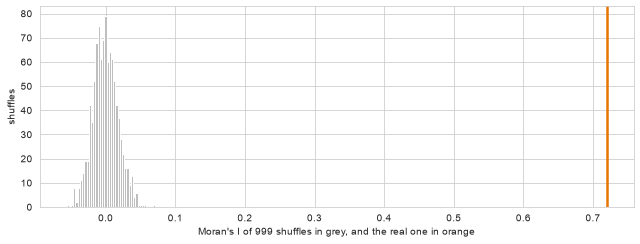

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(test["perm"], bins=40, color="#bfbfbf", edgecolor="white")
ax.axvline(test["I"], color="#e77500", linewidth=2.5)
ax.set_xlabel("Moran's I of 999 shuffles in grey, and the real one in orange")
ax.set_ylabel("shuffles")
fig.tight_layout()

Nine hundred and ninety nine shuffles, and not one of them came anywhere near the real value. The grey pile sits where the expected value says it should, a hair below zero, and the orange line stands alone far to the right. Note that p = 0.001 is a floor, not a measurement. With 999 permutations the smallest p that can be reported is one in a thousand, however strong the pattern. The z score of about forty is the honest way to say how far out the real value sits, i.e. forty standard deviations of the shuffled distribution away from its mean. Note that this p counts only the shuffles that came out at least as high as the observed I, i.e. it asks about clustering. A negative I is a real finding, and it needs the other tail.

## The Moran scatterplot

The same statistic has a picture. Standardise every cell's value, compute the mean of its neighbours' standardised values, i.e. its **spatial lag**, and plot one against the other. Cells in the upper right are high among high neighbours, cells in the lower left are low among low, and the slope of the line through the cloud is Moran's I again, this time under row-standardised weights, i.e. with each cell's neighbours averaged rather than summed. Here is the lag as a function, and the slope through the cloud. Note that `np.add.at` adds into the same slot repeatedly, i.e. it accumulates every neighbour of a cell. The ordinary `lag[i_idx] += v[j_idx]` would quietly keep only one of them, which is the sort of line that gives a wrong answer without an error.

In [10]:
def spatial_lag(values, i_idx, j_idx):
    v = np.asarray(values, dtype=float)
    lag, count = np.zeros(len(v)), np.zeros(len(v))
    np.add.at(lag, i_idx, v[j_idx])
    np.add.at(count, i_idx, 1)
    return lag / np.where(count == 0, 1, count)


z = (real - real.mean()) / real.std()
lag = spatial_lag(z, i_idx, j_idx)
slope, intercept = np.polyfit(z, lag, 1)
print(f"slope {slope:.4f}   reference {reference['moran']['slope_row_standardised']}")

slope 0.6964   reference 0.6964


The slope matches the pipeline's to four decimals. And here is the cloud whose slope that is.

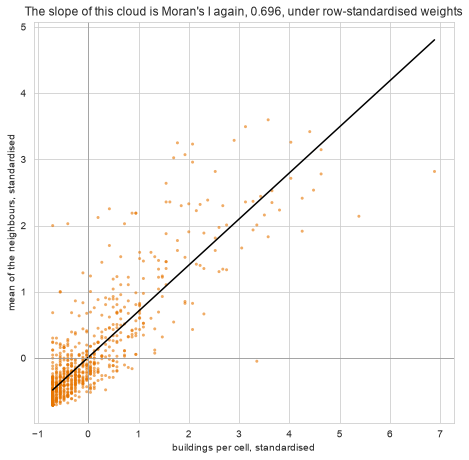

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(z, lag, s=9, color="#e77500", alpha=0.6, edgecolor="none")
xs = np.array([z.min(), z.max()])
ax.plot(xs, slope * xs + intercept, color="black")
ax.axhline(0, color="0.6", linewidth=0.8)
ax.axvline(0, color="0.6", linewidth=0.8)
ax.set_xlabel("buildings per cell, standardised")
ax.set_ylabel("mean of the neighbours, standardised")
ax.set_title(f"The slope of this cloud is Moran's I again, {slope:.3f}, under row-standardised weights")
fig.tight_layout()

Two values of Moran's I for one map, one with binary weights and a slightly smaller one with row-standardised weights, and both are right. They answer slightly different questions about the same neighbours. A published I without its weights is a number without its units, so add a fifth line to the lecture's four when you report one. State your neighbours, and state how you weighted them.

## The same question for the tax blocks

The grid was made to be easy. Every cell has the same size and its neighbours are obvious. Real civic units are neither. Here are the blocks from 02-04 with their assessed value per acre, rebuilt in one cell:

In [12]:
metric = grid.crs
tax_roll = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels").to_crs(metric)
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks").to_crs(metric)

centres = tax_roll.copy()
centres["geometry"] = centres.geometry.centroid
assigned = gpd.sjoin(centres, blocks[["BLOCK_NO", "geometry"]], predicate="within")
assigned = assigned.drop_duplicates("PAMS_PIN")          # five parcels sit in two overlapping blocks, keep one row each
block_value = blocks.dissolve(by="BLOCK_NO")[["geometry"]]
block_value["total"] = assigned.groupby("BLOCK_NO")["NET_VALUE"].sum()
block_value["per_acre"] = block_value["total"] / (block_value.geometry.area / 4046.856)   # square metres to acres, from geometry in metres
valued = block_value.dropna(subset=["per_acre"]).reset_index()

print(f"{len(valued)} blocks with a value   reference {reference['moran_blocks']['blocks']}")

450 blocks with a value   reference 450


Note that this is the total, i.e. every parcel including the exempt ones, and not the taxable rate the poster used, so these 450 blocks and their numbers will not match the lobby map's. Note that the `reset_index` on the last line is load bearing too. The pair arrays are labels from the join and `z[i_idx]` reads positions, so the two agree only while the labels are 0 to n minus 1 and in that order. Sort or filter a layer without resetting and every number after it is quietly about the wrong rows.

Now the wrong intuition, executed. The neighbours function served the grid perfectly, so apply it to the blocks:

In [13]:
ti, tj = neighbours(valued)
isolated = int(np.sum(np.bincount(ti, minlength=len(valued)) == 0))

print(f"{len(ti)} pairs by touching, and {isolated} of {len(valued)} blocks with no neighbour at all, so {len(valued) - isolated} with one")
print(f"reference {reference['moran_blocks']['touches_pairs']} pairs, {reference['moran_blocks']['touches_isolated']} isolated")

250 pairs by touching, and 274 of 450 blocks with no neighbour at all, so 176 with one
reference 250 pairs, 274 isolated


More than half of the blocks have no neighbour, under the definition that just worked. Nothing raised an error, and Moran's I would have happily been computed from the pairs that were found. Look at the map to see why. The view is 1.8 km across, centred on the Engineering Quad where we sit, so it takes in the campus and the blocks around it:

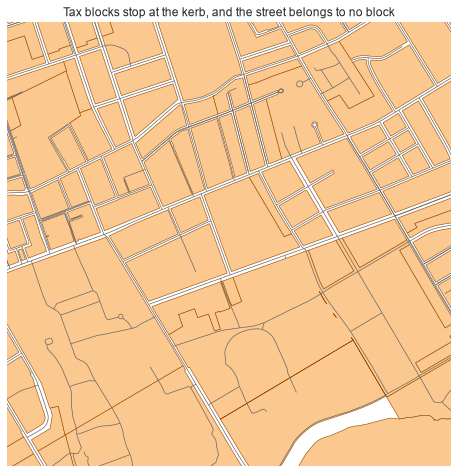

In [14]:
roads = gpd.read_file("data/princeton_municipal.gpkg", layer="roads").to_crs(metric)
landmarks = pd.read_csv("data/landmarks.csv")
here = landmarks[landmarks["id"] == "e225"].iloc[0]
centre = gpd.GeoSeries.from_xy([here["lon"]], [here["lat"]], crs="EPSG:4326").to_crs(metric).iloc[0]
half = 900   # metres, so the view is 1.8 km across

fig, ax = plt.subplots(figsize=(8, 8))
valued.plot(ax=ax, facecolor="#fbc98f", edgecolor="#9c4d00", linewidth=0.6)
roads.plot(ax=ax, color="#666666", linewidth=0.7)
ax.set_xlim(centre.x - half, centre.x + half)
ax.set_ylim(centre.y - half, centre.y + half)
ax.set_title("Tax blocks stop at the kerb, and the street belongs to no block")
ax.set_axis_off()

The grey lines are the municipality's road centrelines. Where a street separates two blocks it runs through white space, because each block is drawn to the edge of the right of way. The lines that do cross an orange shape are driveways and campus roads that serve a single block. The street itself belongs to nobody's block, and so two blocks facing each other across it do not touch. On a grid, contiguity is geometry. On a cadastral map it is a decision about how wide a street may be and still leave its two sides neighbours.

Thirty metres is wider than the gap the blocks leave for an ordinary Princeton street, so let us try it as the rule and see what it finds. Here is the neighbours function with that decision in it, and one more line, because a block is within thirty metres of itself and has to be removed from its own list:

In [15]:
def neighbours_within(gdf, distance):
    nb = gpd.sjoin(gdf[["geometry"]], gdf[["geometry"]], predicate="dwithin", distance=distance)
    nb = nb[nb.index != nb["index_right"]]
    return np.asarray(nb.index), np.asarray(nb["index_right"])


band = 30
bi, bj = neighbours_within(valued, band)
per_block = np.bincount(bi, minlength=len(valued))
print(f"{len(bi)} pairs within {band} m, {int((per_block == 0).sum())} isolated, {per_block.mean():.1f} neighbours per block, from {per_block.min()} to {per_block.max()}")
print(f"reference {reference['moran_blocks']['band_pairs']} pairs within {reference['moran_blocks']['band_m']} m, {reference['moran_blocks']['band_isolated']} isolated")

2678 pairs within 30 m, 0 isolated, 6.0 neighbours per block, from 1 to 19
reference 2678 pairs within 30 m, 0 isolated


Every block has a neighbour now, about six each against the grid's 7.56, though one large block collects nineteen, because a distance band gives a big block more neighbours than a small one. Now the statistic, four times, i.e. for the rate and for the total, under each of the two neighbour definitions:

In [16]:
for column, touch_key, band_key in (("per_acre", "I_per_acre_touches", "I_per_acre"), ("total", "I_total_touches", "I_total")):
    touching = morans_i(valued[column].values, ti, tj)
    within = morans_i(valued[column].values, bi, bj)
    print(f"I of {column:9s}  touching {touching:+.4f}   reference {reference['moran_blocks'][touch_key]:<7}  within {band} m {within:+.4f}   reference {reference['moran_blocks'][band_key]}")

block_test = permutation_test(valued["per_acre"].values, bi, bj)
print(f"value per acre within {band} m: z = {block_test['z']:.1f}, p = {block_test['p']:.3f}")
print(f"the largest value per acre is {valued['per_acre'].max() / valued['per_acre'].median():.0f} times the median")

I of per_acre   touching +0.1800   reference 0.18     within 30 m +0.4819   reference 0.4819
I of total      touching +0.8701   reference 0.8701   within 30 m +0.3748   reference 0.3748
value per acre within 30 m: z = 20.5, p = 0.001
the largest value per acre is 36 times the median


Under the thirty metre band, value per acre clusters, well above zero and far outside anything shuffling produces. The total clusters less under the same neighbours, because a total is partly a map of block size, and size does not run in neighbourhoods the way price does. Under the touching definition both numbers come out differently again, computed from the 176 blocks whose boundaries do meet, where a block line runs along the back of the lots rather than down the middle of a street. Same data, same four lines, four numbers. The one you report is the one whose neighbours you can defend, and the caption says which they were.

Note that the last line matters too. One downtown block carries a value per acre many times the median, and Moran's I on raw values gives a block like that a great deal of say over the result. Analysts often compute it on the logarithm or on ranks instead, and the your-turn cell asks you to see what that changes.

## Your turn

Compute I for value per acre with a 60 m band instead of 30, and then on the logarithm of the value under both bands, adding one dollar first, since a few blocks are assessed at zero. Does the number move? Of the four decisions you have now met, the variable, its transform, the neighbours and the weights, which one moved it most? Write the two sentences you would put in a caption.

In [17]:
# Your attempt.
#
#   neighbours_within(valued, 60)                      a wider band
#   np.log10(valued["per_acre"] + 1)                   the logarithm, with one dollar per acre added so that the blocks assessed at zero survive it
#   morans_i(values, i, j)                             the same four lines as above
#   np.polyfit(z, spatial_lag(z, i, j), 1)[0]          the row-standardised version, with z the standardised values

## Check your understanding

1. The histograms of the real counts and of the shuffled counts were identical. Name two other statistics that would be identical too, and the one that is not.
2. Moran's I came out as two different numbers for the same grid, under binary and under row-standardised weights. Which of the two did the slope of the scatterplot give, and why are both right?
3. On the tax blocks, `touches` left more than half of the blocks with no neighbour. What about the way the blocks are drawn causes that, and what would you have been reporting if you had computed I anyway?
4. The test reported p = 0.001 for the grid. Why can this test never report a smaller p, and which printed number tells you how extreme the observed I really is?

## Where we are

You have computed the lecture's headline statistic from four lines of numpy, tested it by manufacturing chance, drawn its picture, and carried it to a civic unit where the neighbours had to be decided before anything could be computed at all. You have also seen the same statistic come out four ways from one table, and you know which decisions moved it. The fifth question for any map that reports a spatial statistic is now yours to answer. State your neighbours.

## Further resources

Nothing in this course requires anything below.

Tobler's first law of geography, that near things are more related than distant things, is the one sentence this whole notebook rests on, and it appears in Tobler, W. (1970), A computer movie simulating urban growth in the Detroit region, Economic Geography 46, 234 to 240.

The Moran scatterplot and the local version of the statistic, which asks the same question of each cell on its own, are in Anselin, L. (1995), Local indicators of spatial association, Geographical Analysis 27(2), 93 to 115.

The permutation test is the randomisation approach described in Longley, P., Goodchild, M., Maguire, D. and Rhind, D. (2005), Geographic Information Systems and Science, 2nd ed., Wiley, p. 361, the lecture's source for this chapter.

PySAL's `esda` package implements Moran's I, its local version and many neighbour definitions, and is what you would use once you have understood the four lines here: https://pysal.org/esda/

The buildings behind the grid are from OpenStreetMap, ODbL 1.0, and the parcels and blocks from NJGIN Open Data and the Municipality of Princeton, as listed in the data folder's README.

## Appendix, in case you are stuck

Try properly first. If you do use this, treat it the way you would treat an agent's answer. Read it, run it, and say why yours differed.

```python
import geopandas as gpd
import numpy as np

metric = "EPSG:26918"
tax_roll = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels").to_crs(metric)
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks").to_crs(metric)
centres = tax_roll.copy()
centres["geometry"] = centres.geometry.centroid
assigned = gpd.sjoin(centres, blocks[["BLOCK_NO", "geometry"]], predicate="within")
assigned = assigned.drop_duplicates("PAMS_PIN")          # five parcels sit in two overlapping blocks, keep one row each
block_value = blocks.dissolve(by="BLOCK_NO")[["geometry"]]
block_value["total"] = assigned.groupby("BLOCK_NO")["NET_VALUE"].sum()
block_value["per_acre"] = block_value["total"] / (block_value.geometry.area / 4046.856)   # square metres to acres, from geometry in metres
valued = block_value.dropna(subset=["per_acre"]).reset_index()


def pairs_within(gdf, distance):
    nb = gpd.sjoin(gdf[["geometry"]], gdf[["geometry"]], predicate="dwithin", distance=distance)
    nb = nb[nb.index != nb["index_right"]]
    return np.asarray(nb.index), np.asarray(nb["index_right"])


def morans_i(values, i, j):
    z = np.asarray(values, dtype=float) - np.mean(values)
    return (len(z) / len(i)) * float(np.sum(z[i] * z[j])) / float(np.sum(z ** 2))


for distance in (30, 60):
    i, j = pairs_within(valued, distance)
    raw = morans_i(valued["per_acre"], i, j)
    logged = morans_i(np.log10(valued["per_acre"] + 1), i, j)
    print(f"within {distance} m   I of the raw value {raw:+.3f}   I of its logarithm {logged:+.3f}")
```

Both decisions move the number. Which one moved it more is the first sentence of your caption, and the fact that it moved at all is the second.